### ReAct Agent Architecture

This is the intuition behind ReAct, a general agent architecture.

1. act - let the model call specific tools
2. observe - pass the tool output back to the model
3. reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

In [37]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [38]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [39]:
arxiv.invoke("Attention iss all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [40]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [44]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper
import wikipedia

wikipedia.wikipedia.API_URL = "https://en.wikipedia.org/w/api.php"
wikipedia.wikipedia.USER_AGENT = "RAG-learning-notebook/1.0 (local educational project)"


In [45]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation m'

In [46]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"]="ReAct-agent"

In [47]:
### Custom Functions
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools=[arxiv,wiki,add,multiply,divide]

In [48]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [49]:
tavily.invoke("Provide me the recent AI news for march 3rd 2025")

[{'title': 'Weekly AI News: 3 March 2025 - AIforBusiness.net',
  'url': 'https://www.linkedin.com/pulse/weekly-ai-news-3-march-2025-aiforbusinessnet-johan-steyn-qrumf',
  'content': "### Johan Steyn\n\nSubscribe to our newsletter: \n\nThis week’s AI update explores some of the most impactful developments shaping technology and society. OpenAI has unveiled GPT-4.5, a cutting-edge model with enhanced intuition and emotional intelligence. While its capabilities push AI closer to human-like perception, its high computational demands raise concerns about accessibility, particularly for smaller businesses.\n\nMeanwhile, AI is revolutionising taxation. The IMF reports that governments are leveraging AI to detect fraud and streamline audits, while taxpayers benefit from automated filing systems. However, privacy and fairness remain key concerns. [...] A thought-provoking analysis in the Daily Maverick questions AI’s growing influence, warning that biases within AI systems could shape decision-

In [50]:
### Combine all the tools in the list

tools=[arxiv,wiki,tavily,add,divide,multiply]

In [51]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="llama-3.3-70b-versatile")

llm_with_tools=llm.bind_tools(tools)

In [52]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ned8bwd3e', 'function': {'arguments': '{"query":"recent AI news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 744, 'total_tokens': 764, 'completion_time': 0.06854644, 'prompt_time': 0.130947648, 'queue_time': 0.036228865, 'total_time': 0.199494088}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019efb85-4de7-7c00-b929-aa7cac25d358-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent AI news'}, 'id': 'ned8bwd3e', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 744, 'output_tokens': 20, 'total_tokens': 764})

In [53]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

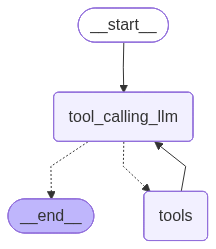

In [54]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [60]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (3y7jf9gw0)
 Call ID: 3y7jf9gw0
  Args:
    query: top 10 recent AI news March 3rd 2025
  add (607j4ngg3)
 Call ID: 607j4ngg3
  Args:
    a: 5
    b: 5
  multiply (zyc11n02s)
 Call ID: zyc11n02s
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "The 10 Biggest AI News Stories Of 2025", "url": "https://www.crn.com/news/ai/2025/the-10-biggest-ai-news-stories-of-2025", "content": "# The 10 Biggest AI News Stories Of 2025\n\nThe AI industry in 2025 saw big-money acquisitions, advancements in virtual assistants and agent orchestration, and new innovations in hardware.\n\nTechnological Iceberg as t

In [61]:
messages=graph.invoke({"messages":HumanMessage(content="add 5 plus 5 and then multiply by 10")})
#messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})

#messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  add (n38dbkt7b)
 Call ID: n38dbkt7b
  Args:
    a: 5
    b: 5
  multiply (k7f5emggs)
 Call ID: k7f5emggs
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: add

10
================================= Tool Message =================================
Name: multiply

100
================================== Ai Message ==================================

First, 5 + 5 = 10. Then, 10 * 10 = 100.
